<a href="https://colab.research.google.com/github/clearlyclear/NLP_Final/blob/main/binary_model_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IAT 360 - Group 6 Sarcasm Detector (BERT/Hugging Face/PyTorch)

**Group notes:**
1. Set runtime to GPU T4 on top right so we don't accidentally start a fusion reaction out of our CPU
2. Double check that 'TRAIN_PATH' and 'TEST_PATH' follow the correct paths
3. There's almost a **MILLION** rows in the training set and it'll likely take over an hour to train, set 'TRAIN_SUBSET' to something like 5000 instead to test if it works. The best model will be uploaded to the Drive each epoch so don't worry about disconnects

##Project Description

Caustic and humorous wordplay is a linguistic phenomena that would likely fall flat to an untrained AI. We’d like to try and train an NLP model to classify whether a social media comment is sarcastic or not, which may help avoid any miscommunications between an AI misinterpreting an ironic statement as literal. This could be useful for training virtual assistant chatbots to detect client emotions, and help break the ice of a person’s views towards virtual assistants.

##Model

We'll be transfer training Google's Bidirectional Encoder Representations from Transformers (BERT) model. We found it useful for the fact that it was already pre-trained by Google on the English language so that we may train it to detect sarcasm. One issue is that the old notebook, among several issues like swapped paths (training on the test set, and testing on the giant training set) and manually importing zip files of BERT weights, also used a library we couldn't use in Colab. We had to instead import it from Hugging Face, which no longer supported TensorFlow in favour of PyTorch.

Dataset - https://www.kaggle.com/datasets/wenxindong/sarcasm
Old Code - https://www.kaggle.com/code/wenxindong/binary-model

In [1]:
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 60.9 MB/s eta 0:00:00


In [2]:
import torch, transformers
print("torch", torch.__version__)
print("transformers", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

torch 2.11.0+cu128
transformers 5.14.1
CUDA available: True


In [3]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: no GPU detected. Switch the runtime to GPU before training.")

Using device: cuda


In [4]:
import os, shutil
from google.colab import drive

assert not os.path.ismount('/content/drive'), "Drive is mounted doot trash it"
shutil.rmtree('/content/drive', ignore_errors=True) #trash any lingering data from any failed runs
drive.mount('/content/drive')

print(os.listdir('/content/drive/MyDrive/NLP_Final'))

Mounted at /content/drive
['Datasets']


Verify that the Drive is mounted

In [5]:
import os
print("drive mounted:", os.path.ismount('/content/drive'))
print(os.listdir('/content/drive/MyDrive/NLP_Final'))

drive mounted: True
['Datasets']


## Load the data from Drive

`TRAIN_SUBSET` lets you train on a random assortment of however much you want while you're testing the pipeline set it back to `None` for the whole thing (don't)

In [15]:
from sklearn.model_selection import train_test_split

TRAIN_PATH = "/content/drive/MyDrive/NLP_Final/Datasets/sarcastic_binary_train.csv"
TEST_PATH  = "/content/drive/MyDrive/NLP_Final/Datasets/sarcastic_binary_test.csv"
SAVE_DIR   = "/content/drive/MyDrive/NLP_Final/Ju_Checkpoint/best_model"
TRAIN_SUBSET = 50000 # Training set size hyperparameter, Make sure TRAIN_SUBSET is None if you want to train the entire dataset

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
print("raw:", train_df.shape, test_df.shape)

# --- OLD: val = 10% of full pool (~90-100k, way oversized) ---
# train_df, val_df = train_test_split(
#     train_df,
#     test_size=0.1,
#     stratify=train_df["label"],
#     random_state=42
# )

# --- NEW: val = fixed absolute count (~16,666 total, ~8,333/class) ---
train_df, val_df = train_test_split(
    train_df,
    test_size=16500,        # absolute count, not a fraction
    stratify=train_df["label"],
    random_state=42
)
print("split ->  train:", train_df.shape, " val:", val_df.shape, " test:", test_df.shape)

raw: (1008773, 3) (2000, 2)
split ->  train: (992273, 3)  val: (16500, 3)  test: (2000, 2)


prepared: (50000, 3) (16317, 3) (1988, 3)
label
1    0.5012
0    0.4988


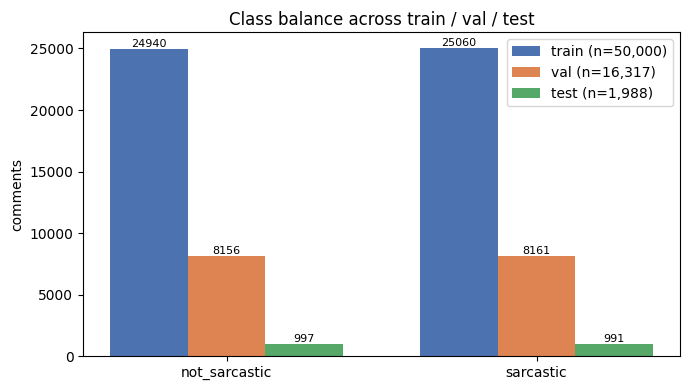

In [16]:
import matplotlib.pyplot as plt

def clean(text):
    text = re.sub(r"https?://\S+|www\.\S+", "", str(text))
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare(df):
    df = df.drop_duplicates()
    if "sample_weight" not in df.columns:
        df = df.assign(sample_weight=1.0)
    df = df[["text", "label", "sample_weight"]].dropna(subset=["text", "label"])
    df = df.assign(text=df["text"].map(clean))
    df = df[df["text"].str.len() > 0].reset_index(drop=True)
    return df

train_df = prepare(train_df)
test_df  = prepare(test_df)
# --- NEW: val_df needs the same cleaning as train_df/test_df ---
val_df   = prepare(val_df)

if TRAIN_SUBSET is not None: #Pick (TRAIN_SUBSET) amount of rows to sample from, the rows are randomly picked. Since the full dataset is balanced, on average, so will the subset
    train_df = train_df.sample(TRAIN_SUBSET, random_state=42).reset_index(drop=True)

print("prepared:", train_df.shape, val_df.shape, test_df.shape)
print(train_df["label"].value_counts(normalize=True).to_string())

import numpy as np

labels = ["not_sarcastic", "sarcastic"]
splits = {
    f"train (n={len(train_df):,})": train_df["label"].value_counts().sort_index(),
    f"val (n={len(val_df):,})":     val_df["label"].value_counts().sort_index(),
    f"test (n={len(test_df):,})":   test_df["label"].value_counts().sort_index(),
}

x = np.arange(len(labels))       # positions for not_sarcastic / sarcastic
width = 0.25                     # width of each bar within a group
colors = ["#4C72B0", "#DD8452", "#55A868"]

plt.figure(figsize=(7, 4))
for i, (split_name, counts) in enumerate(splits.items()):
    # reindex in case a label is missing (e.g. 0 count), fill with 0
    counts = counts.reindex([0, 1], fill_value=0)
    offset = (i - 1) * width  # centers the three bars around each tick
    bars = plt.bar(x + offset, counts.values, width, label=split_name, color=colors[i])
    plt.bar_label(bars, fontsize=8)

plt.xticks(x, labels)
plt.ylabel("comments")
plt.title("Class balance across train / val / test")
plt.legend()
plt.tight_layout()
plt.show()

## Tokenize

Prepare the dataset and getters for PyTorch to process. Each comment packed with its label and weight

In [17]:
class SarcasmDataset(Dataset):
    def __init__(self, enc, labels, weights):
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = list(labels)
        self.weights = list(weights)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.input_ids[i],
            "attention_mask": self.attention_mask[i],
            "label": self.labels[i],
            "weight": self.weights[i],
        }

##Trainer

In [20]:
import os, time, gc, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

assert os.path.ismount('/content/drive'), "Drive not mounted — mount before running."

#HYPERPARAMS
MODELS      = ["distilbert-base-uncased", "bert-base-uncased", "roberta-base"]
EPOCHS      = 3
LR          = 2e-5
BATCH_SIZE  = 16
MAX_LEN     = 128
SEED        = 42
MODELS_ROOT = "/content/drive/MyDrive/NLP_Final/Models"

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def build_loaders(tokenizer):
    def collate(batch):
        padded = tokenizer.pad(
            {"input_ids": [b["input_ids"] for b in batch],
             "attention_mask": [b["attention_mask"] for b in batch]},
            return_tensors="pt")
        padded["labels"]  = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        padded["weights"] = torch.tensor([b["weight"] for b in batch], dtype=torch.float)
        return padded

    # --- OLD ---
    # te_enc = tokenizer(list(test_df["text"]),  truncation=True, max_length=MAX_LEN)
    # te = SarcasmDataset(te_enc, test_df["label"],  test_df["sample_weight"])

    # --- NEW: use val_df for the loop that trains/selects checkpoints ---
    tr_enc = tokenizer(list(train_df["text"]), truncation=True, max_length=MAX_LEN)
    va_enc = tokenizer(list(val_df["text"]),   truncation=True, max_length=MAX_LEN)
    tr = SarcasmDataset(tr_enc, train_df["label"], train_df["sample_weight"])
    va = SarcasmDataset(va_enc, val_df["label"],   val_df["sample_weight"])
    return (DataLoader(tr, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate),
            DataLoader(va, batch_size=64, shuffle=False, collate_fn=collate))

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    preds, gold = [], []
    total_loss, total_n = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = torch.nn.functional.cross_entropy(logits.float(), labels)
        total_loss += loss.item() * labels.size(0)
        total_n += labels.size(0)
        preds.extend(logits.argmax(-1).cpu().tolist())
        gold.extend(labels.cpu().tolist())
    return {"loss": total_loss / total_n, "acc": accuracy_score(gold, preds),
            "f1": f1_score(gold, preds), "precision": precision_score(gold, preds),
            "recall": recall_score(gold, preds)}

runs = {}
for name in MODELS:
    print(f"\n=== {name} ===")
    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(name)
    # train_loader, test_loader = build_loaders(tokenizer)
    train_loader, val_loader = build_loaders(tokenizer)
    model = AutoModelForSequenceClassification.from_pretrained(name, num_labels=2).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
    loss_fn = nn.CrossEntropyLoss(reduction="none")

    save_dir = os.path.join(MODELS_ROOT, name.replace("/", "_"), "best_model")
    os.makedirs(save_dir, exist_ok=True)

    history, best_f1 = [], 0.0
    t0 = time.time()
    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for batch in tqdm(train_loader, desc=f"{name} epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            weights = batch["weights"].to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                loss = (loss_fn(logits, labels) * weights).mean()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running += loss.item()
        # val = evaluate_model(model, test_loader)
        val = evaluate_model(model, val_loader)
        history.append({"epoch": epoch + 1, "train_loss": running / len(train_loader),
                        "val_loss": val["loss"], "val_acc": val["acc"], "val_f1": val["f1"],
                        "val_precision": val["precision"], "val_recall": val["recall"]})
        print(f"  epoch {epoch+1}  train_loss={running/len(train_loader):.4f}  "
              f"val_loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}")
        if val["f1"] > best_f1:
            best_f1 = val["f1"]
            model.save_pretrained(save_dir)
            tokenizer.save_pretrained(save_dir)

    elapsed = time.time() - t0
    runs[name] = {"history": history, "best_f1": best_f1,
                  "save_dir": save_dir, "minutes": elapsed / 60,
                  "lr": LR, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
                  "max_len": MAX_LEN, "n_train": int(len(train_df)), "seed": SEED}
    print(f"  done: best_f1={best_f1:.4f}  time={elapsed/60:.1f} min  saved -> {save_dir}")

    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n=== summary ===")
for name, r in runs.items():
    print(f"{name:28s}  best_f1={r['best_f1']:.4f}  {r['minutes']:.1f} min")


=== distilbert-base-uncased ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert-base-uncased epoch 1:   0%|          | 0/3125 [00:00<?, ?it/s]

  epoch 1  train_loss=0.6376  val_loss=0.5439  acc=0.7199  f1=0.6868


...

roberta-base epoch 2:   0%|          | 0/3125 [00:00<?, ?it/s]

  epoch 2  train_loss=0.5345  val_loss=0.5414  acc=0.7376  f1=0.7411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

roberta-base epoch 3:   0%|          | 0/3125 [00:00<?, ?it/s]

  epoch 3  train_loss=0.4335  val_loss=0.5727  acc=0.7393  f1=0.7394
  done: best_f1=0.7411  time=15.5 min  saved -> /content/drive/MyDrive/NLP_Final/Models/roberta-base/best_model

=== summary ===
distilbert-base-uncased       best_f1=0.7211  8.8 min
bert-base-uncased             best_f1=0.7319  14.5 min
roberta-base                  best_f1=0.7411  15.5 min


##Results

scoring distilbert-base-uncased ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

scoring bert-base-uncased ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

scoring roberta-base ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

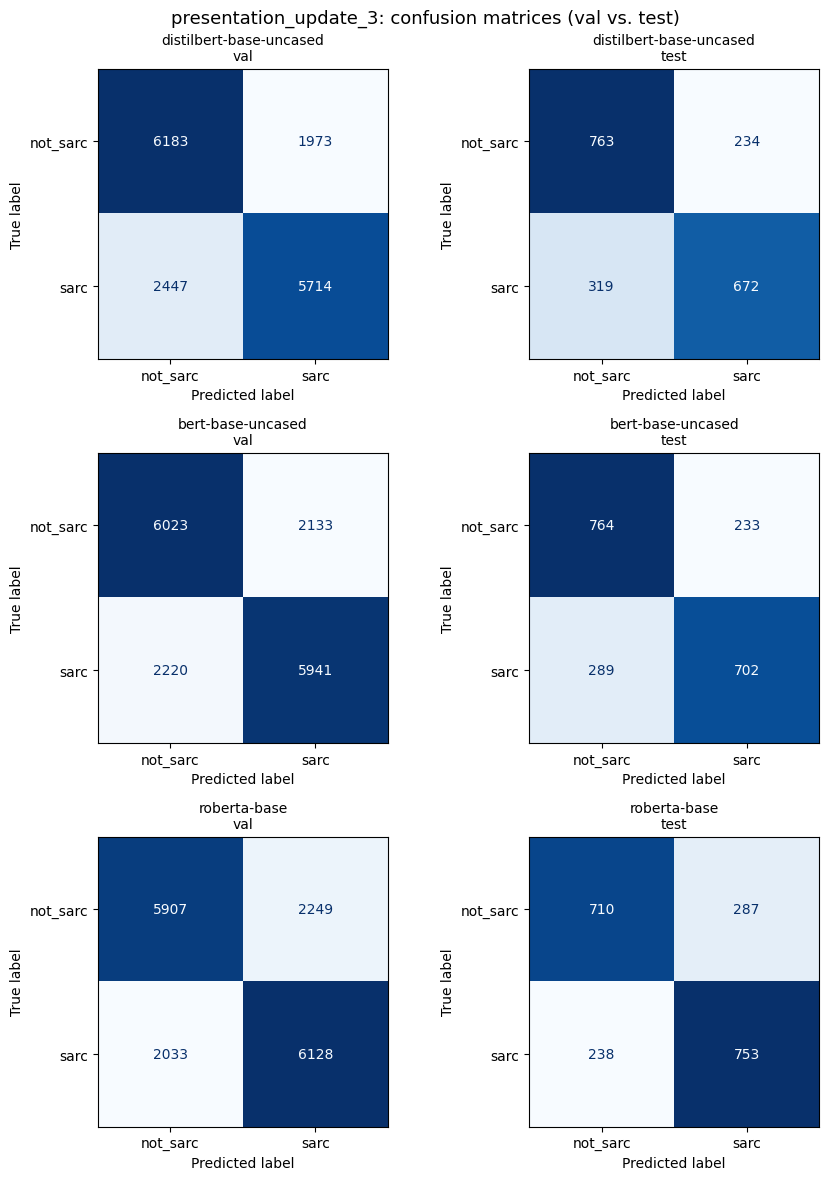


=== val vs. test comparison ===
             model_name  val_accuracy  val_f1  test_accuracy  test_f1  train_minutes
           roberta-base        0.7376  0.7411         0.7359   0.7415          15.51
      bert-base-uncased        0.7332  0.7319         0.7374   0.7290          14.47
distilbert-base-uncased        0.7291  0.7211         0.7218   0.7085           8.79


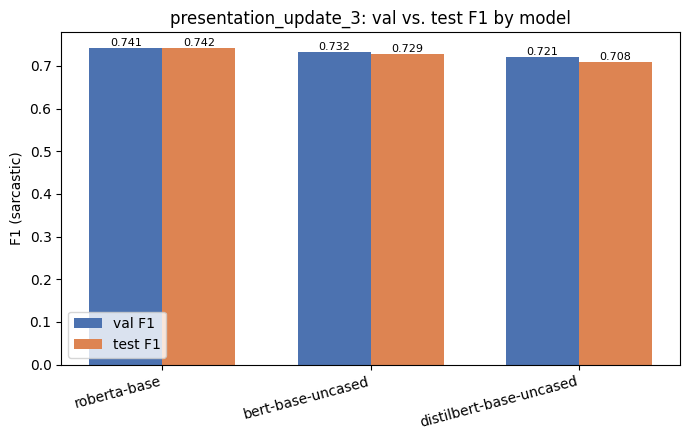

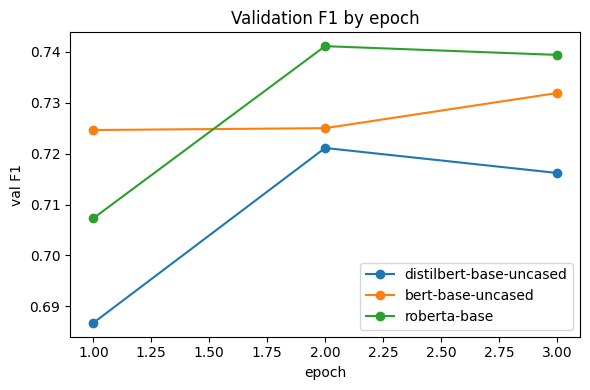


Saved experiment to: /content/drive/MyDrive/NLP_Final/Results/presentation_update_3
Appended 3 rows to: /content/drive/MyDrive/NLP_Final/Results/all_runs.csv


In [28]:
import os, json, datetime, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

assert "runs" in globals() and len(runs) > 0, "Run the back-to-back training cell first — 'runs' is empty."

EXPERIMENT_NAME = "presentation_update"
RESULTS_ROOT = "/content/drive/MyDrive/NLP_Final/Results"

def next_run_dir(root, name):
    os.makedirs(root, exist_ok=True)
    idxs = [int(d[len(name)+1:]) for d in os.listdir(root)
            if d.startswith(name + "_") and d[len(name)+1:].isdigit()]
    idx = max(idxs) + 1 if idxs else 1
    path = os.path.join(root, f"{name}_{idx}")
    os.makedirs(path, exist_ok=True)
    return path, idx

def _smooth(y, frac=0.15):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 5:
        return y
    w = max(3, int(round(n * frac)))
    if w % 2 == 0:
        w += 1
    ypad = np.pad(y, w // 2, mode="edge")
    return np.convolve(ypad, np.ones(w) / w, mode="valid")

def plot_dashboard(history, out_path, title, show=False):
    h = pd.DataFrame(history)
    x = h["epoch"].values
    panels = [("train/loss", "train_loss"), ("eval/loss", "val_loss"),
              ("metrics/accuracy", "val_acc"), ("metrics/precision", "val_precision"),
              ("metrics/recall", "val_recall"), ("metrics/f1", "val_f1")]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (name, key) in zip(axes.ravel(), panels):
        if key not in h.columns:
            ax.set_visible(False)
            continue
        y = h[key].values
        ax.plot(x, y, marker="o", label="results")
        if len(y) >= 5:
            ax.plot(x, _smooth(y), linestyle=":", label="smooth")
        ax.set_title(name); ax.set_xlabel("epoch"); ax.set_xticks(x); ax.grid(alpha=0.2)
    axes.ravel()[0].legend()
    fig.suptitle(title); fig.tight_layout(); fig.savefig(out_path, dpi=120)
    plt.show() if show else plt.close(fig)

@torch.no_grad()
def predict_df(model, tokenizer, df, max_len=128, batch_size=64):
    model.eval()
    enc = tokenizer(list(df["text"]), truncation=True, max_length=max_len)
    ds = SarcasmDataset(enc, df["label"], df["sample_weight"])
    def collate(batch):
        padded = tokenizer.pad(
            {"input_ids": [b["input_ids"] for b in batch],
             "attention_mask": [b["attention_mask"] for b in batch]},
            return_tensors="pt")
        padded["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        return padded
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
    preds, probs = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        p = torch.softmax(logits.float(), dim=-1)
        preds.extend(p.argmax(-1).cpu().tolist())
        probs.extend(p[:, 1].cpu().tolist())
    out = df.copy()
    out["predicted"] = preds
    out["prob_sarcastic"] = probs
    out["correct"] = (out["predicted"] == out["label"]).astype(int)
    return out

# --- NEW: helper to compute+save the same metric bundle for any split ---
def score_split(mdl, tok, df, split_name, mdir, r, max_len):
    pred_df = predict_df(mdl, tok, df, max_len=max_len)
    pred_df.to_csv(os.path.join(mdir, f"{split_name}_predictions.csv"), index=False)

    errors = pred_df[pred_df["correct"] == 0].copy()
    errors["confidence"] = np.where(errors["predicted"] == 1,
                                    errors["prob_sarcastic"], 1 - errors["prob_sarcastic"])
    errors.sort_values("confidence", ascending=False).to_csv(
        os.path.join(mdir, f"{split_name}_confident_mistakes.csv"), index=False)

    gold, preds = pred_df["label"].tolist(), pred_df["predicted"].tolist()
    metrics = {
        "accuracy": float(accuracy_score(gold, preds)),
        "f1_sarcastic": float(f1_score(gold, preds)),
        "f1_macro": float(f1_score(gold, preds, average="macro")),
        "precision": float(precision_score(gold, preds)),
        "recall": float(recall_score(gold, preds)),
        "n": int(len(df)),
    }

    with open(os.path.join(mdir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(gold, preds, target_names=["not_sarcastic", "sarcastic"]))

    cm = confusion_matrix(gold, preds)
    np.savetxt(os.path.join(mdir, f"{split_name}_confusion_matrix.csv"), cm, fmt="%d", delimiter=",")
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["not_sarcastic", "sarcastic"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"{split_name} — {r['save_dir'].split('/')[-2]}"); plt.tight_layout()
    plt.savefig(os.path.join(mdir, f"{split_name}_confusion_matrix.png"), dpi=120); plt.close(fig)

    return metrics

exp_dir, exp_idx = next_run_dir(RESULTS_ROOT, EXPERIMENT_NAME)
summary_rows = []

for name, r in runs.items():
    print(f"scoring {name} ...")
    mdir = os.path.join(exp_dir, name.replace("/", "_"))
    os.makedirs(mdir, exist_ok=True)

    tok = AutoTokenizer.from_pretrained(r["save_dir"])
    mdl = AutoModelForSequenceClassification.from_pretrained(r["save_dir"]).to(device)

    # --- OLD: only test_df was scored here ---
    # pred_df = predict_df(mdl, tok, test_df, max_len=r["max_len"])
    # ...
    # gold, preds = pred_df["label"].tolist(), pred_df["predicted"].tolist()
    # m = { "accuracy": ..., "f1_sarcastic": ..., ... }  # test-only, flat keys

    # --- NEW: score val_df AND test_df with the same metric bundle ---
    val_metrics  = score_split(mdl, tok, val_df,  "val",  mdir, r, r["max_len"])
    test_metrics = score_split(mdl, tok, test_df, "test", mdir, r, r["max_len"])

    m = {
        "experiment": EXPERIMENT_NAME, "experiment_index": exp_idx, "model_name": name,
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        # val metrics (final saved checkpoint, re-scored, not just the training-time peak)
        "val_accuracy": val_metrics["accuracy"], "val_f1": val_metrics["f1_sarcastic"],
        "val_f1_macro": val_metrics["f1_macro"], "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"], "n_val": val_metrics["n"],
        # test metrics (the one true held-out set)
        "test_accuracy": test_metrics["accuracy"], "test_f1": test_metrics["f1_sarcastic"],
        "test_f1_macro": test_metrics["f1_macro"], "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"], "n_test": test_metrics["n"],
        # training-time metadata
        "best_val_f1_during_training": float(r["best_f1"]), "train_minutes": round(r["minutes"], 2),
        "learning_rate": r["lr"], "epochs": r["epochs"], "batch_size": r["batch_size"],
        "max_len": r["max_len"], "n_train": r["n_train"],
        "seed": r["seed"], "torch": torch.__version__, "transformers": transformers.__version__,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    }
    with open(os.path.join(mdir, "metrics.json"), "w") as f:
        json.dump(m, f, indent=2)
    pd.DataFrame(r["history"]).to_csv(os.path.join(mdir, "history.csv"), index=False)
    plot_dashboard(r["history"], os.path.join(mdir, "results.png"), name, show=False)

    summary_rows.append(m)
    del mdl; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

compare = pd.DataFrame(summary_rows).sort_values("test_f1", ascending=False).reset_index(drop=True)
compare.to_csv(os.path.join(exp_dir, "comparison.csv"), index=False)

# --- NEW: combined confusion matrix grid — all models, val + test, side by side ---
n_models = len(runs)
fig, axes = plt.subplots(n_models, 2, figsize=(9, 4 * n_models))
if n_models == 1:
    axes = axes.reshape(1, 2)  # keep 2D indexing consistent if only one model

for i, (name, r) in enumerate(runs.items()):
    for j, split_name in enumerate(["val", "test"]):
        mdir = os.path.join(exp_dir, name.replace("/", "_"))
        cm = np.loadtxt(os.path.join(mdir, f"{split_name}_confusion_matrix.csv"),
                         delimiter=",", dtype=int)
        ax = axes[i, j]
        disp = ConfusionMatrixDisplay(cm, display_labels=["not_sarc", "sarc"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{name}\n{split_name}", fontsize=10)

fig.suptitle(f"{EXPERIMENT_NAME}_{exp_idx}: confusion matrices (val vs. test)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(exp_dir, "all_confusion_matrices.png"), dpi=120)
plt.show()

# --- NEW: clean side-by-side val/test table, easy to read at a glance ---
print("\n=== val vs. test comparison ===")
display_cols = ["model_name", "val_accuracy", "val_f1", "test_accuracy", "test_f1", "train_minutes"]
print(compare[display_cols].round(4).to_string(index=False))

# --- NEW: grouped bar chart — val F1 vs test F1, per model, side by side ---
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(compare))
width = 0.35
bars1 = ax.bar(x - width/2, compare["val_f1"],  width, label="val F1",  color="#4C72B0")
bars2 = ax.bar(x + width/2, compare["test_f1"], width, label="test F1", color="#DD8452")
ax.bar_label(bars1, fmt="%.3f", fontsize=8)
ax.bar_label(bars2, fmt="%.3f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(compare["model_name"], rotation=15, ha="right")
ax.set_ylabel("F1 (sarcastic)")
ax.set_title(f"{EXPERIMENT_NAME}_{exp_idx}: val vs. test F1 by model")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(exp_dir, "val_vs_test_comparison.png"), dpi=120)
plt.show()

# learning curves plot unchanged
fig, ax = plt.subplots(figsize=(6, 4))
for name, r in runs.items():
    h = pd.DataFrame(r["history"])
    ax.plot(h["epoch"], h["val_f1"], marker="o", label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("val F1"); ax.set_title("Validation F1 by epoch"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(exp_dir, "learning_curves.png"), dpi=120); plt.show()

master = os.path.join(RESULTS_ROOT, "all_runs.csv")
new = pd.DataFrame(summary_rows)
combined = pd.concat([pd.read_csv(master), new], ignore_index=True) if os.path.exists(master) else new
combined.to_csv(master, index=False)
print("\nSaved experiment to:", exp_dir)
print("Appended", len(summary_rows), "rows to:", master)

## Test Best Model Here


In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

BEST_MODEL = max(runs, key=lambda n: runs[n]["best_f1"])
SAVE_DIR = runs[BEST_MODEL]["save_dir"] #Assign the best model out of the 3 in this run
print("Testing:", BEST_MODEL)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tok = AutoTokenizer.from_pretrained(SAVE_DIR)
mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
mdl.eval()

@torch.no_grad()
def predict(text):
    enc = tok(text, truncation=True, max_length=128, return_tensors="pt").to(device)
    probs = torch.softmax(mdl(**enc).logits, dim=-1)[0]
    label = "sarcastic" if probs[1] > probs[0] else "not_sarcastic"
    return label, probs[1].item()

label, conf = predict("Oh, well that's just great. Very good job there, idiot!")
print(f"{label}  (p_sarcastic={conf:.2f})")

Testing: roberta-base


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sarcastic  (p_sarcastic=0.74)


In [26]:
import os, datetime
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

LOG_PATH = os.path.join(SAVE_DIR, "live_predictions.csv")

text_box   = widgets.Textarea(placeholder="Type a comment here...",
                              layout=widgets.Layout(width="500px", height="60px"))
predict_btn = widgets.Button(description="Predict", button_style="primary")
result_out  = widgets.Output()
feedback_box = widgets.HBox([])
status_out  = widgets.Output()

state = {}

def log_row(true_label):
    row = {
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        "text": state["text"],
        "predicted": state["pred_label"],
        "prob_sarcastic": round(state["prob"], 4),
        "true_label": true_label,
        "correct": int(state["pred_label"] == true_label),
    }
    pd.DataFrame([row]).to_csv(LOG_PATH, mode="a",
                              header=not os.path.exists(LOG_PATH), index=False)

def on_feedback(correct):
    true_label = state["pred_label"] if correct else (
        "not_sarcastic" if state["pred_label"] == "sarcastic" else "sarcastic")
    log_row(true_label)
    with status_out:
        clear_output()
        n = len(pd.read_csv(LOG_PATH))
        print(f"Logged. Recorded true label: {true_label}.  Total in log: {n}")
    feedback_box.children = ()

def on_predict(_):
    text = text_box.value.strip()
    with status_out:
        clear_output()
    with result_out:
        clear_output()
        if not text:
            print("Type something first.")
            return
        label, prob = predict(text)
        state.update(text=text, pred_label=label, prob=prob)
        print(f"Prediction: {label}   (p_sarcastic={prob:.2f})")
    if not text:
        return
    correct_btn = widgets.Button(description="Correct", button_style="success")
    wrong_btn   = widgets.Button(description="Wrong", button_style="danger")
    correct_btn.on_click(lambda _: on_feedback(True))
    wrong_btn.on_click(lambda _: on_feedback(False))
    feedback_box.children = (widgets.Label("Was it right?"), correct_btn, wrong_btn)

predict_btn.on_click(on_predict)
display(widgets.VBox([text_box, predict_btn, result_out, feedback_box, status_out]))